In [1]:
import torch
from utils import visualize_sample_image_from_dataloader
from data_setup import create_dataloaders
from torchvision import transforms

label
genuine    1403
fraud       190
Name: count, dtype: int64

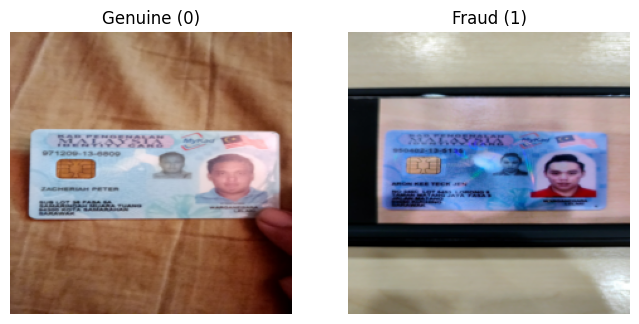

In [2]:
train_batch = [ "batch_production_202207_redone_rejectedcase/index_annotation.csv",
				#"batch_production_202209_redone_rejectedcase/index_annotation.csv",
				#"batch_legacy_20221026_subset/index_annotation_ori.csv",
                ]

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

train_dataset, validation_dataset, train_loader, validation_loader, class_names  = create_dataloaders(train_list=train_batch, transform=transform, batch_size=4)

# try out the train_dataset (Custom pytorch dataset object)
display(train_dataset.label_counts())

visualize_sample_image_from_dataloader(train_loader)

In [6]:
# Add this to your notebook after the dataloader setup

from model_builder import CustomClassifierModel
from engine import train
import torch.nn as nn

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REPO_DIR = "/home/jingjie/dev/dino/dinov3"
CHECKPOINT_PATH = "/home/jingjie/dev/dino/DinoClassifier/models/dinov3_vits16_pretrain_lvd1689m-08c60483.pth"

# Load backbone
dinov3_vits16 = torch.hub.load(REPO_DIR, 'dinov3_vits16', source='local', weights=CHECKPOINT_PATH)

# Create model
model = CustomClassifierModel(
    backbone_model=dinov3_vits16,
    backbone_model_output_dim=384,
    freeze_backbone=False  # freeze for faster testing
).to(device)

# Train
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

results = train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=validation_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=10,  # quick test
    device=device
)

  0%|          | 0/10 [00:14<?, ?it/s]


KeyboardInterrupt: 